In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)

In [2]:
X_iris = iris.data[['petal length (cm)', 'petal width (cm)']].values
y_iris = iris.target

In [3]:
tree_clf = DecisionTreeClassifier(max_depth = 2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [4]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file = 'iris_tree.dot',
    feature_names = ['petal length (cm)', 'petal width (cm)'],
    class_names = iris.target_names,
    rounded= True,
    filled = True
)


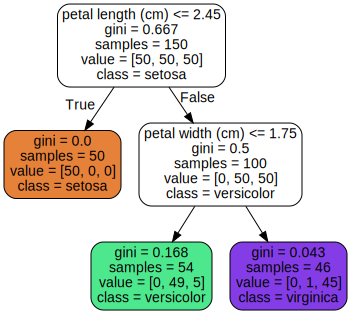

In [5]:
from graphviz import Source
Source.from_file('iris_tree.dot')

In [6]:
import numpy as np
import matplotlib.pyplot as plt


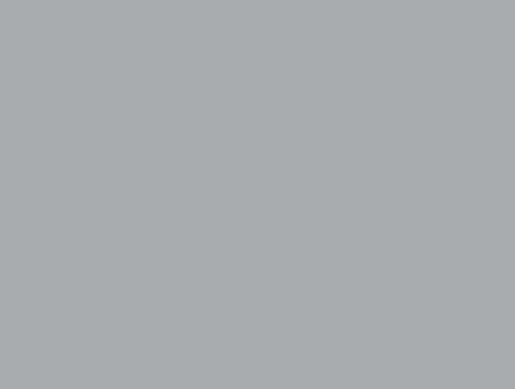

In [7]:
plt.figure(facecolor='#abacad')  
plt.axis('off')
plt.show()

In [8]:
len(np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))[0][0])

100

In [9]:
enumerate(zip(iris.target_names, ("yo", "bs", "g^")))

In [11]:
X_iris[:5]

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

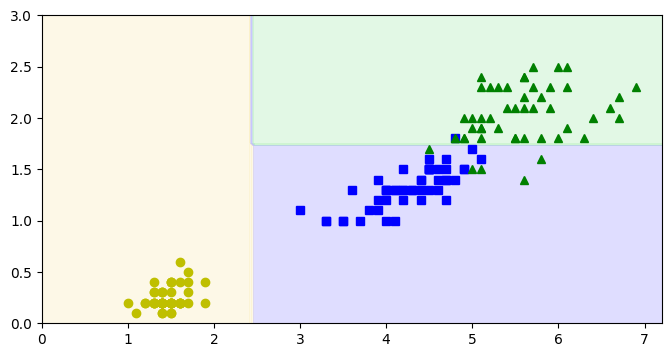

In [15]:
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#faebb0', '#9591ff', '#a0eba9'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)

for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx], style, label =f'iris {name}')

In [16]:
tree_clf.tree_.impurity

array([0.66666667, 0.        , 0.5       , 0.16803841, 0.04253308])

In [17]:
tree_clf.predict_proba([[5,1.6]])

array([[0.        , 0.90740741, 0.09259259]])

In [18]:
tree_clf.predict([[5,1.6]])

array([1])

*Because Decision Trees do not assume much about the data (have very low **bias**), they act like a chameleon, adapting to whatever data is presented to it. Hence, it has a high **variance** and needs to be regularised*

In [19]:
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=150, noise = 0.2, random_state=42)

In [20]:
tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2= DecisionTreeClassifier(min_samples_leaf=5, random_state=42) ##Constrained Model

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

In [21]:
export_graphviz(
    tree_clf1,
    out_file = 'unregularized.dot',
    rounded= True,
    filled = True
)

export_graphviz(
    tree_clf2,
    out_file = 'regularized.dot',
    rounded= True,
    filled = True
)

In [24]:
tree_clf1.tree_.capacity

37

In [25]:
tree_clf2.tree_.capacity

25

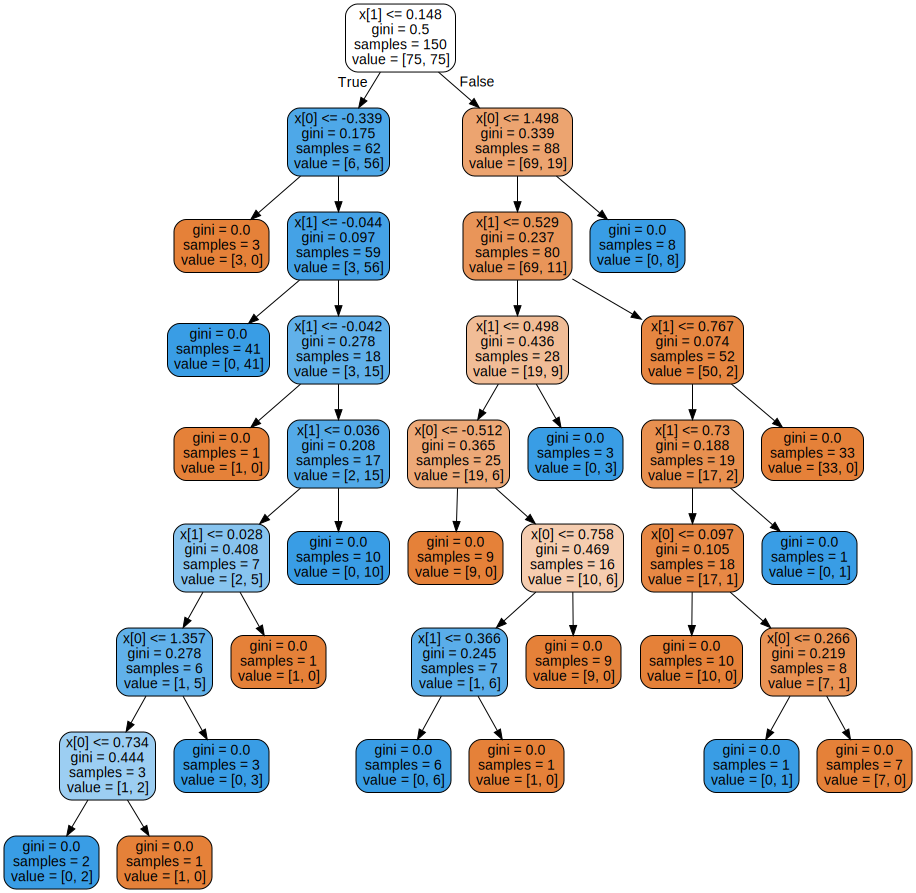

In [26]:
Source.from_file('unregularized.dot')

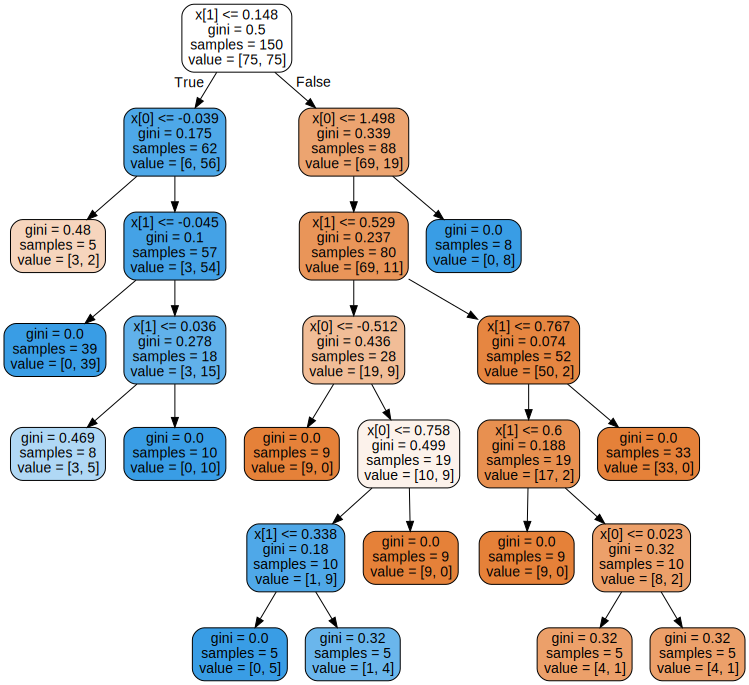

In [27]:
Source.from_file('regularized.dot')

In [28]:
len(X_moons[0])

2

def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)


fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")


plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Pastel1")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")



*Clearly, the model on the right seems like it would generalise much better*

In [30]:
X_moons_test, y_moons_test= make_moons(n_samples=1000, noise = 0.2, random_state=43)

tree_clf1.score(X_moons_test, y_moons_test)

0.898

In [31]:
tree_clf2.score(X_moons_test, y_moons_test)

0.92

*As expected*

*One limitation of Decision Trees are the orthogonal boundaries. They can't incline the hyperplane*

*For this reason, we apply PCA before using Decision trees, in order to minimise the feature correlation*

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

pca_pipe = make_pipeline(StandardScaler(), PCA())
X_iris_rotated= pca_pipe.fit_transform(X_iris)
tree_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_pca.fit(X_iris_rotated, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

Text(0.5, 1.0, 'min_samples_leaf = 5')

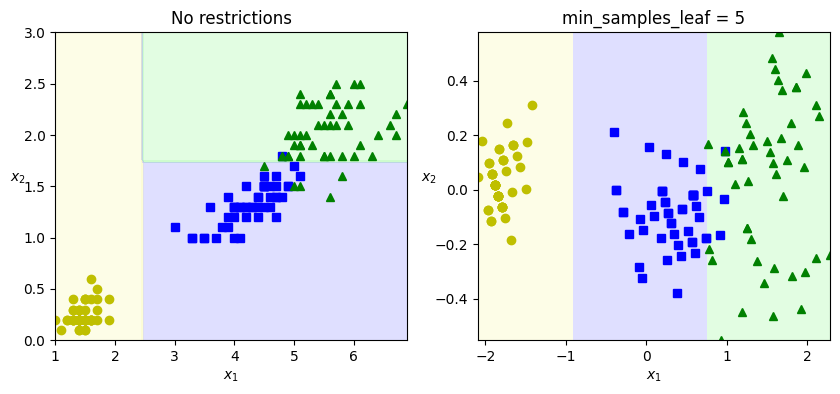

In [38]:
def plot_decision_boundary(clf, X, y, axes):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    
    custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx], style, label =f'iris {name}')
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)


fig, axes = plt.subplots(ncols=2, figsize=(10, 4))
plt.sca(axes[0])
x_min = X_iris[:,0].min()
x_max = X_iris[:,0].max()
plot_decision_boundary(tree_clf, X_iris, y_iris, [x_min, x_max, 0, 3])
plt.title("No restrictions")


plt.sca(axes[1])
pca_min = X_iris_rotated[:,0].min()
pca_max = X_iris_rotated[:,0].max()
pca_x2_min = X_iris_rotated[:,1].min() 
pca_x2_max = X_iris_rotated[:,1].max() 
plot_decision_boundary(tree_pca, X_iris_rotated, y_iris, [pca_min, pca_max, pca_x2_min, pca_x2_max])
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")

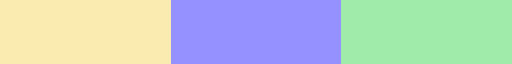

In [39]:
custom_cmap

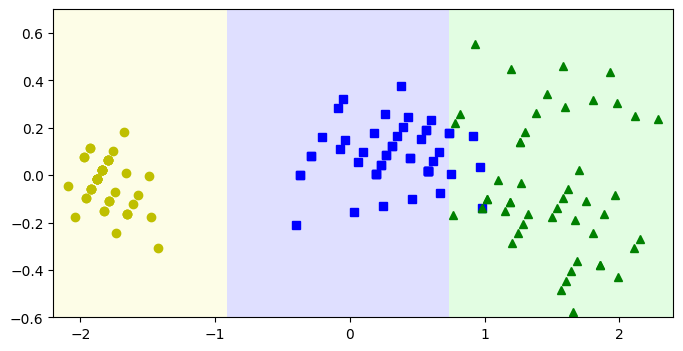

In [36]:
plt.figure(figsize=(8, 4))

axes = [-2.2, 2.4, -0.6, 0.7]
z0s, z1s = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                       np.linspace(axes[2], axes[3], 100))
X_iris_pca_all = np.c_[z0s.ravel(), z1s.ravel()]
y_pred = tree_pca.predict(X_iris_pca_all).reshape(z0s.shape)


plt.contourf(z0s, z1s, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris_rotated[:, 0][y_iris == idx],
             X_iris_rotated[:, 1][y_iris == idx],
             style, label=f"Iris {name}")



In [39]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X_moons, y_moons = make_moons(n_samples=10000, noise = 0.2, random_state=42)
X_train, X_test, y_train, y_test=  train_test_split(X_moons, y_moons, test_size=0.2, random_state= 42)


In [40]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_leaf_nodes': list(range(2, 100)),
    'max_depth': list(range(1, 7)),
    'min_samples_split': [2, 3, 4]
}
grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42),
                              params,
                              cv=3)

grid_search_cv.fit(X_train, y_train)

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6],
                         'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                            13, 14, 15, 16, 17, 18, 19, 20, 21,
                                            22, 23, 24, 25, 26, 27, 28, 29, 30,
                                            31, ...],
                         'min_samples_split': [2, 3, 4]})

In [41]:
grid_search_cv.best_estimator_

DecisionTreeClassifier(max_depth=6, max_leaf_nodes=15, random_state=42)

In [42]:
grid_search_cv.best_estimator_

DecisionTreeClassifier(max_depth=6, max_leaf_nodes=15, random_state=42)

In [43]:
from sklearn.metrics import accuracy_score

y_pred = grid_search_cv.predict(X_test)
accuracy_score(y_test, y_pred)

0.966

In [44]:
grid_search_cv.score(X_test, y_test)

0.966

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test,y_pred))

[[961  52]
 [ 16 971]]


In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1013
           1       0.95      0.98      0.97       987

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [47]:
from sklearn.model_selection import ShuffleSplit

n_trees = 1000
n_instances =100

mini_sets = []

rs = ShuffleSplit(n_splits=n_trees, test_size=len(X_train) - n_instances,
                  random_state=42)

for mini_train_index, mini_test_index in rs.split(X_train):
    X_mini_train = X_train[mini_train_index]
    y_mini_train = y_train[mini_train_index]
    mini_sets.append((X_mini_train, y_mini_train))

In [48]:
arr = []
tree = []
for i in range(1000):
    tree_clf = DecisionTreeClassifier(max_depth=6, max_leaf_nodes=15)
    tree_clf.fit(mini_sets[i][0], mini_sets[i][1])
    tree.append(tree_clf)
    y_pred = tree_clf.predict(X_test)
    arr.append(accuracy_score(y_test, y_pred))

In [53]:
from sklearn.base import clone

forest = [clone(grid_search_cv.best_estimator_) for _ in range(n_trees)]

accuracy_scores = []

for tree, (X_mini_train, y_mini_train) in zip(forest, mini_sets):
    tree.fit(X_mini_train, y_mini_train)
    
    y_pred = tree.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

np.mean(accuracy_scores)

0.9268040000000001

In [56]:
Y_pred = np.empty([n_trees, len(X_test)], dtype=np.uint8)

In [59]:
len(Y_pred[0])

2000

In [64]:
enumerate(forest)

In [65]:
for tree_index, tree in enumerate(forest):
    Y_pred[tree_index] = tree.predict(X_test)

In [73]:
from scipy.stats import mode
y_pred_majority_votes, n_votes = mode(Y_pred, axis=0)

In [74]:
accuracy_score(y_test, y_pred_majority_votes.reshape([-1]))

0.969

In [75]:
from scipy.stats import mode
Y_pred = []
y_pred = []



Y_pred = np.array([tree.predict(X_test) for tree in forest])
y_pred_majority_votes, _ = mode(Y_pred, axis=0)



In [76]:
accuracy_score(y_test, y_pred_majority_votes.reshape([-1]))

0.969